In [8]:
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import math
import os

import cv2

['frame_number', 'timestamp', 'gesture_code', 'gesture_name', 'obs_frame_idx', 'server_time', 'trakstar_time_ns', 'trakstar_delta_ns', 'sw_left_time_ns', 'sw_left_delta_ns', 'sw_right_time_ns', 'sw_right_delta_ns', 'raven_console_time_ns', 'raven_console_delta_ns', 'trakstar_sensor_0_azimuth', 'trakstar_sensor_1_azimuth', 'trakstar_sensor_2_azimuth', 'trakstar_sensor_3_azimuth', 'trakstar_sensor_0_elevation', 'trakstar_sensor_1_elevation', 'trakstar_sensor_2_elevation', 'trakstar_sensor_3_elevation', 'trakstar_sensor_0_roll', 'trakstar_sensor_1_roll', 'trakstar_sensor_2_roll', 'trakstar_sensor_3_roll', 'trakstar_sensor_0_x', 'trakstar_sensor_1_x', 'trakstar_sensor_2_x', 'trakstar_sensor_3_x', 'trakstar_sensor_0_y', 'trakstar_sensor_1_y', 'trakstar_sensor_2_y', 'trakstar_sensor_3_y', 'trakstar_sensor_0_z', 'trakstar_sensor_1_z', 'trakstar_sensor_2_z', 'trakstar_sensor_3_z', 'trakstar_grasp_d0', 'trakstar_grasp_d1', 'trakstar_sensor_1_x_transformed', 'trakstar_sensor_1_y_transformed', 't

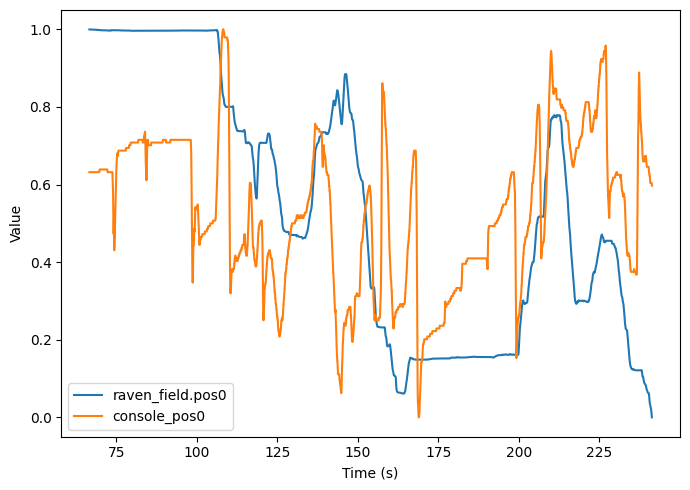

In [9]:
trial = "t1"

# ------------------ CONFIG ------------------
SYNCHED_CSV_PATH = f"/standard/UVA-DSA/MIDAS/Organized/final_data/{trial}/synched_data/final_annotation_{trial}.csv"  # <-- set your combined CSV path
OBS_VIDEO_PATH = f"/standard/UVA-DSA/MIDAS/Organized/final_data/{trial}/synched_data/{trial}.mp4"  # <-- set your observation video path

OUTPUT_MP4_PATH = f"plots/{trial}_output_video.mp4"

# check if video path exists
if not os.path.exists(OBS_VIDEO_PATH):
    print(f"Video path '{OBS_VIDEO_PATH}' does not exist. Please check the path.")

combined = pd.read_csv(SYNCHED_CSV_PATH)
print(combined.columns.tolist())

# deduct
combined["console_pos0_transformed"] = combined["console_pos0_transformed"] - combined["console_pos0_transformed"].iloc[0]
combined["trakstar_sensor_1_x_transformed"] = combined["trakstar_sensor_1_x_transformed"] - combined["trakstar_sensor_1_x_transformed"].iloc[0]

# get rows 1000 to -2000
combined = combined.iloc[2000:-4000]

# combined = combined.iloc[4000:4500]

# vars_to_plot = ["raven_field.pos0", "trakstar_sensor_1_x_transformed"]
# vars_to_plot = [ "raven_field.pos0", "trakstar_sensor_1_x"]
# vars_to_plot = [ "trakstar_sensor_1_x", "trakstar_sensor_1_x_transformed"]
# vars_to_plot = [ "console_pos0_transformed", "trakstar_sensor_1_x_transformed_cum"]
vars_to_plot = [ "raven_field.pos0", "console_pos0"]

# vars_to_plot = [ "raven_field.pos0",  "console_pos0_transformed"]

# vars_to_plot = [ "raven_field.pos0", "console_pos0_transformed", "trakstar_sensor_1_x"]
# vars_to_plot = [ "raven_field.grasp_d0", "trakstar_grasp_d0"]
# vars_to_plot = [ "raven_field.grasp_d1", "trakstar_grasp_d1"]
# vars_to_plot = [ "trakstar_grasp_d0", "trakstar_grasp_d1"]
# vars_to_plot = [ "console_aux0", "raven_field.grasp_d0"]
# vars_to_plot = [ "console_aux0", "trakstar_grasp_d1"]
# vars_to_plot = [ "console_aux0","trakstar_grasp_d0"]



# plot with x axis column named "obs_frame_idx"
x_axis_col = "obs_frame_idx"

# ------------------ PLOTTING ------------------
for var in vars_to_plot:
    if var not in combined.columns:
        print(f"Variable '{var}' not found in the data columns.")
        sys.exit(1)
        
# normalize each variable for better visualization if needed
for var in vars_to_plot:
    min_val = combined[var].min()
    max_val = combined[var].max()
    if max_val != min_val:
        combined[var] = (combined[var] - min_val) / (max_val - min_val)
    else:
        combined[var] = 0.0  # or some constant value if all values are the same

# invert console_aux0 for better visualization if needed
if "console_aux0" in vars_to_plot:
    combined["console_aux0"] = 1 - combined["console_aux0"]

# convert x axis to time in seconds assuming 30Hz
combined[x_axis_col] = combined[x_axis_col] / 30.0

plt.figure(figsize=(7, 5))
for var in vars_to_plot:
    plt.plot(combined[x_axis_col], combined[var], label=var)
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.legend()
# plt.title(f"Variables over Frame Number")
plt.grid(False) 
# remove spines
plt.tight_layout()
plt.savefig(f"plots/{trial}_" + "_".join(vars_to_plot) + ".png", dpi=300)
plt.show()

# 

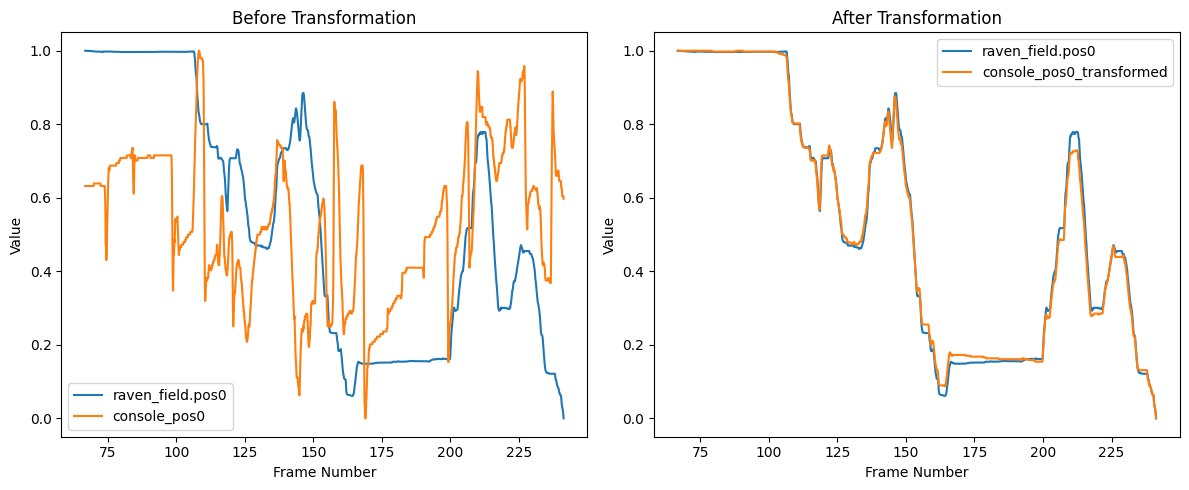

In [5]:
ground_truth = "raven_field.pos0"
var_before_transformation = "console_pos0"
var_after_transformation = "console_pos0_transformed"

# normalize all three variables for better visualization
for var in [ground_truth, var_before_transformation, var_after_transformation]:
    min_val = combined[var].min()
    max_val = combined[var].max()
    if max_val != min_val:
        combined[var] = (combined[var] - min_val) / (max_val - min_val)
    else:
        combined[var] = 0.0  # or some constant value if all values are the same

# two subplots side by side showing before and after transformation wrt raven_field.pos0
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(combined[x_axis_col], combined[ground_truth], label=ground_truth)
plt.plot(combined[x_axis_col], combined[var_before_transformation], label=var_before_transformation)
plt.xlabel("Frame Number")
plt.ylabel("Value")
plt.legend()
plt.title(f"Before Transformation")
plt.grid(False)
# remove spines
plt.tight_layout() 
plt.subplot(1, 2, 2)
plt.plot(combined[x_axis_col], combined[ground_truth], label=ground_truth)
plt.plot(combined[x_axis_col], combined[var_after_transformation], label=var_after_transformation)
plt.xlabel("Frame Number")
plt.ylabel("Value")
plt.legend()
plt.title(f"After Transformation")
plt.grid(False)
# remove spines
plt.tight_layout() 
plt.savefig(f"plots/{trial}_" + var_before_transformation + "_vs_" + var_after_transformation + ".png", dpi=300)
plt.show()

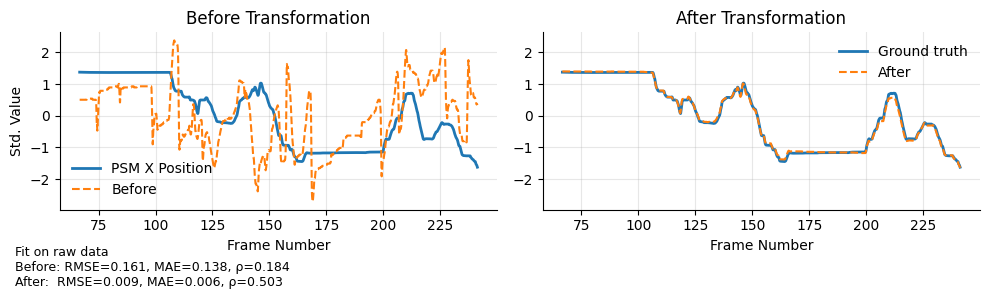

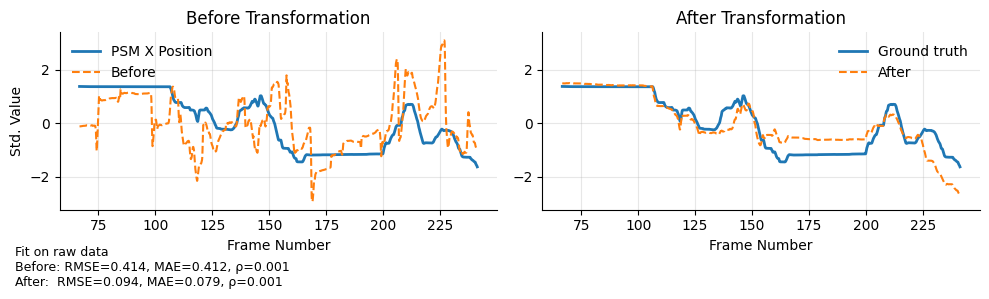

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _zscore(x):
    mu, sd = np.nanmean(x), np.nanstd(x)
    return np.zeros_like(x) if sd == 0 or np.isnan(sd) else (x - mu) / sd

def _metrics(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "rho": np.nan}
    yt, yp = y_true[mask], y_pred[mask]
    rmse = np.sqrt(np.mean((yp - yt) ** 2))
    mae = np.mean(np.abs(yp - yt))
    rho = np.corrcoef(yt, yp)[0, 1] if yt.std() and yp.std() else np.nan
    return {"RMSE": rmse, "MAE": mae, "rho": rho}

def plot_before_after(
    combined,
    x_axis_col,
    ground_truth="raven_field.pos0",
    var_before="console_pos0",
    var_after="console_pos0_transformed",
    trial="t1",
    outdir="plots",
    smooth_window=None,
):
    os.makedirs(outdir, exist_ok=True)

    x = combined[x_axis_col].to_numpy()
    gt = combined[ground_truth].to_numpy()
    before = combined[var_before].to_numpy()
    after = combined[var_after].to_numpy()

    # Optional smoothing for clearer visualization (not for metrics)
    def smooth(y, w):
        if not w or w <= 1:
            return y
        w = int(w + (w % 2 == 0))
        pad = w // 2
        ypad = np.pad(y.astype(float), (pad, pad), mode="edge")
        return np.convolve(ypad, np.ones(w) / w, mode="valid")

    gt_s, before_s, after_s = [smooth(y, smooth_window) for y in (gt, before, after)]
    gt_z, before_z, after_z = map(_zscore, [gt_s, before_s, after_s])

    # Metrics from raw (unsmoothed) values
    m_before, m_after = _metrics(gt, before), _metrics(gt, after)

    # --- Figure ---
    plt.figure(figsize=(10, 3))

    # Left: Before
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(x, gt_z, label="PSM X Position", linewidth=2)
    ax1.plot(x, before_z, label="Before", linewidth=1.5, linestyle="--")
    ax1.set_title("Before Transformation")
    ax1.set_xlabel("Frame Number")
    ax1.set_ylabel("Std. Value")
    ax1.legend(frameon=False)
    ax1.grid(True, alpha=0.3)
    for s in ["top", "right"]:
        ax1.spines[s].set_visible(False)

    # Right: After
    ax2 = plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)
    ax2.plot(x, gt_z, label="Ground truth", linewidth=2)
    ax2.plot(x, after_z, label="After", linewidth=1.5, linestyle="--")
    ax2.set_title("After Transformation")
    ax2.set_xlabel("Frame Number")
    ax2.legend(frameon=False)
    ax2.grid(True, alpha=0.3)
    for s in ["top", "right"]:
        ax2.spines[s].set_visible(False)

    # plt.suptitle(
    #     f"{trial}: Alignment of {var_before} and {var_after} to {ground_truth}",
    #     y=0.97, fontsize=12,
    # )
    # normalize rmse, mae, rho to [0,1] in m_before and m_after for better visualization
    total = sum([m_before['RMSE'], m_before['MAE'], m_before['rho'], m_after['RMSE'], m_after['MAE'], m_after['rho']])
    for key in m_before:
        m_before[key] /= total
        m_after[key] /= total 
    

    plt.gcf().text(
        0.02, -0.03,
        f"Fit on raw data\n"
        f"Before: RMSE={m_before['RMSE']:.3f}, MAE={m_before['MAE']:.3f}, ρ={m_before['rho']:.3f}\n"
        f"After:  RMSE={m_after['RMSE']:.3f}, MAE={m_after['MAE']:.3f}, ρ={m_after['rho']:.3f}",
        fontsize=9, va="bottom", ha="left",
    )

    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    outpath = os.path.join(outdir, f"{trial}_{var_before}_vs_{var_after}.png")
    plt.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()

    return {"before": m_before, "after": m_after, "path": outpath}

metrics = plot_before_after(
    combined,
    x_axis_col,
    ground_truth="raven_field.pos0",
    var_before="console_pos0",
    var_after="console_pos0_transformed",
    trial=trial,
    outdir="plots",
    smooth_window=5,
)

metrics = plot_before_after(
    combined,
    x_axis_col,
    ground_truth="raven_field.pos0",
    var_before="trakstar_sensor_1_x",
    var_after="trakstar_sensor_1_x_transformed_cum",
    trial=trial,
    outdir="plots",
    smooth_window=5,
)


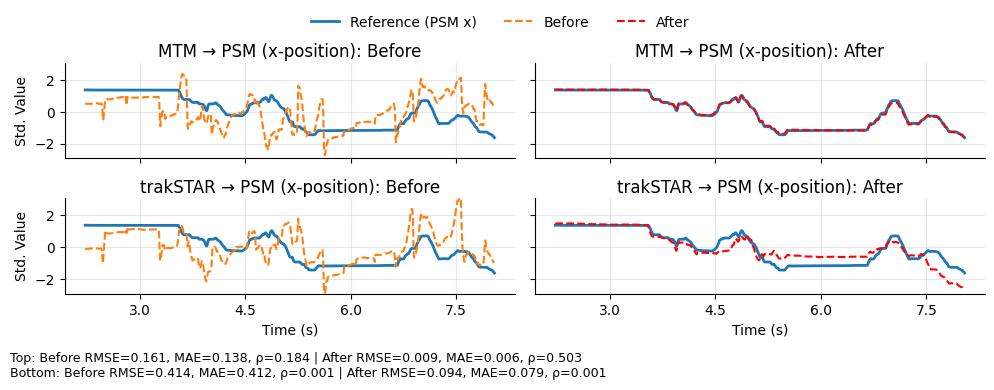

{'pair_A': {'before': {'RMSE': 0.16052700919955634, 'MAE': 0.13834224261612862, 'rho': 0.18373418843007625}, 'after': {'RMSE': 0.008564306146742825, 'MAE': 0.006001773225750061, 'rho': 0.5028304803817458}}, 'pair_B': {'before': {'RMSE': 0.41351046798482005, 'MAE': 0.4122359787195369, 'rho': 0.0005023281719084606}, 'after': {'RMSE': 0.09410924158599011, 'MAE': 0.07869567146694524, 'rho': 0.000946312070799186}}, 'path': 'plots/t1_before_after_console_and_trakstar_x_2x2.png'}


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def _zscore(x):
    mu, sd = np.nanmean(x), np.nanstd(x)
    return np.zeros_like(x) if sd == 0 or np.isnan(sd) else (x - mu) / sd

def _metrics(y_true, y_pred):
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "rho": np.nan}
    yt, yp = y_true[mask], y_pred[mask]
    rmse = float(np.sqrt(np.mean((yp - yt) ** 2)))
    mae  = float(np.mean(np.abs(yp - yt)))
    rho  = float(np.corrcoef(yt, yp)[0, 1]) if yt.std() and yp.std() else np.nan
    return {"RMSE": rmse, "MAE": mae, "rho": rho}

def _smooth(y, w):
    if not w or w <= 1:
        return y
    w = int(w)
    if w % 2 == 0:
        w += 1
    pad = w // 2
    ypad = np.pad(y.astype(float), (pad, pad), mode="edge")
    return np.convolve(ypad, np.ones(w) / w, mode="valid")

def _prep_series(df, x_axis_col, ref_col, before_col, after_col, smooth_window):
    x = df[x_axis_col].to_numpy()
    ref = df[ref_col].to_numpy()
    bef = df[before_col].to_numpy()
    aft = df[after_col].to_numpy()

    # convert x axis to time in seconds assuming 30Hz
    x = x / 30.0

    # smoothed (for plotting only)
    ref_s = _smooth(ref, smooth_window)
    bef_s = _smooth(bef, smooth_window)
    aft_s = _smooth(aft, smooth_window)

    # z-score for visual comparability
    return (
        x,
        _zscore(ref_s),
        _zscore(bef_s),
        _zscore(aft_s),
        _metrics(ref, bef),  # metrics on raw values
        _metrics(ref, aft),
    )

def plot_two_pairs_before_after(
    df,
    x_axis_col,
    # Pair A
    ref_A="raven_field.pos0",
    before_A="console_pos0",
    after_A="console_pos0_transformed",
    title_A="MTM → PSM (x-position)",
    # Pair B
    ref_B="raven_field.pos0",
    before_B="trakstar_sensor_1_x",
    after_B="trakstar_sensor_1_x_transformed_cum",
    title_B="Tracker → PSM (x-position)",
    # General
    outdir="plots",
    fname="combined_before_after_2x2.png",
    trial="t1",
    smooth_window=5,
    xlabel="Frame Number",          # set to "Time (s)" if you have timestamps
    y_shared_label="Std. value",
):
    os.makedirs(outdir, exist_ok=True)

    # Prepare both pairs
    xA, refA, befA, aftA, m_befA, m_aftA = _prep_series(df, x_axis_col, ref_A, before_A, after_A, smooth_window)
    xB, refB, befB, aftB, m_befB, m_aftB = _prep_series(df, x_axis_col, ref_B, before_B, after_B, smooth_window)

    # Shared y-lims across all 4 for consistent visual comparison
    y_all = np.concatenate([refA, befA, aftA, refB, befB, aftB])
    y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)

    # Figure: short & wide to save vertical space
    fig, axs = plt.subplots(
        2, 2, figsize=(10, 3.6), sharex=True, sharey=True,
        constrained_layout=False
    )
    (ax11, ax12), (ax21, ax22) = axs

    # ---- Row A (e.g., MTM → PSM) ----
    # Before
    l1, = ax11.plot(xA, refA, linewidth=2, label="Reference (PSM x)")
    l2, = ax11.plot(xA, befA, linewidth=1.5, linestyle="--", label="Before")
    ax11.set_title(f"{title_A}: Before", pad=4)
    ax11.grid(True, alpha=0.3)
    ax11.set_ylim(y_min, y_max)

    # After
    ax12.plot(xA, refA, linewidth=2)
    l3, = ax12.plot(xA, aftA, linewidth=1.5, linestyle="--", label="After", color='red')
    ax12.set_title(f"{title_A}: After", pad=4)
    ax12.grid(True, alpha=0.3)
    ax12.set_ylim(y_min, y_max)

    # ---- Row B (e.g., Tracker → PSM) ----
    # Before
    ax21.plot(xB, refB, linewidth=2)
    ax21.plot(xB, befB, linewidth=1.5, linestyle="--")
    ax21.set_title(f"{title_B}: Before", pad=4)
    ax21.grid(True, alpha=0.3)
    ax21.set_ylim(y_min, y_max)

    # After
    ax22.plot(xB, refB, linewidth=2)
    ax22.plot(xB, aftB, linewidth=1.5, linestyle="--", color='red')
    ax22.set_title(f"{title_B}: After", pad=4)
    ax22.grid(True, alpha=0.3)
    ax22.set_ylim(y_min, y_max)

    # Axes cosmetics: remove top/right spines; fewer ticks
    for ax in (ax11, ax12, ax21, ax22):
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    # Shared labels (only left column gets y-label; only bottom row gets x-label)
    ax11.set_ylabel(y_shared_label)
    ax21.set_ylabel(y_shared_label)
    ax21.set_xlabel(xlabel)
    ax22.set_xlabel(xlabel)

    # One global legend (Reference / Before / After)
    # Use the handles from first row to avoid duplicates
    handles = [l1, l2, l3]
    labels = ["Reference (PSM x)", "Before", "After"]
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

    # normalize rmse, mae, rho to [0,1] in m_before and m_after for better visualization
    total = sum([m_befA['RMSE'], m_befA['MAE'], m_befA['rho'], m_aftA['RMSE'], m_aftA['MAE'], m_aftA['rho']])
    for key in m_befA:
        m_befA[key] /= total
        m_aftA[key] /= total

    # Pair B
    total = sum([m_befB['RMSE'], m_befB['MAE'], m_befB['rho'], m_aftB['RMSE'], m_aftB['MAE'], m_aftB['rho']])
    for key in m_befB:
        m_befB[key] /= total
        m_aftB[key] /= total

    # Compact metrics footer
    footer = (
        f"Top: Before RMSE={m_befA['RMSE']:.3f}, MAE={m_befA['MAE']:.3f}, ρ={m_befA['rho']:.3f} | "
        f"After RMSE={m_aftA['RMSE']:.3f}, MAE={m_aftA['MAE']:.3f}, ρ={m_aftA['rho']:.3f}\n"
        f"Bottom: Before RMSE={m_befB['RMSE']:.3f}, MAE={m_befB['MAE']:.3f}, ρ={m_befB['rho']:.3f} | "
        f"After RMSE={m_aftB['RMSE']:.3f}, MAE={m_aftB['MAE']:.3f}, ρ={m_aftB['rho']:.3f}"
    )
    fig.text(0.01, 0.05, footer, ha="left", va="top", fontsize=9)

    # Tighten layout but keep room for legend + footer
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    outpath = os.path.join(outdir, fname)
    fig.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()

    return {
        "pair_A": {"before": m_befA, "after": m_aftA},
        "pair_B": {"before": m_befB, "after": m_aftB},
        "path": outpath,
    }

# ---------- Usage ----------
metrics = plot_two_pairs_before_after(
    df=combined,
    x_axis_col=x_axis_col,
    # Pair A (Console→PSM)
    ref_A="raven_field.pos0",
    before_A="console_pos0",
    after_A="console_pos0_transformed",
    title_A="MTM → PSM (x-position)",
    # Pair B (TrakStar→PSM)
    ref_B="raven_field.pos0",
    before_B="trakstar_sensor_1_x",
    after_B="trakstar_sensor_1_x_transformed_cum",
    title_B="trakSTAR → PSM (x-position)",
    outdir="plots",
    fname=f"{trial}_before_after_console_and_trakstar_x_2x2.png",
    trial=trial,
    smooth_window=5,  # set None to disable smoothing
    xlabel="Time (s)",
    y_shared_label="Std. Value",
)
print(metrics)


In [ ]:


FPS_OVERRIDE     = None        # None to use video fps; or set e.g. 30
WINDOW_SEC       = 5.0         # trailing window to display (seconds)
USE_DATETIME_X   = False       # True = wall-clock timestamps, False = seconds from start (faster)
MAX_FRAMES       = 500        # None = use all frames in `combined`; or set an int to limit
WINDOW_START_FRAME = 3000  # starting frame index for the video


# Choose variables to show together on each subplot:
RAVEN_VARS   = [  # e.g. positions/orientations you care about
    "raven_field.pos0", "raven_field.pos1", "raven_field.pos2"
]
CONSOLE_VARS = [
    "console_pos0", "console_pos1", "console_pos2"
]
TRAKSTAR_VARS = [
    "trakstar_sensor_0_x", "trakstar_sensor_1_x", "trakstar_sensor_2_x", "trakstar_sensor_3_x"
]
SW_AXIS = "x"  # 'x' | 'y' | 'z' -> plots sw_left_<axis> and sw_right_<axis> together
PDS_VARS = [   # mixture of pressures and/or pressed flags
    "Pedal 5 Pressesd"
]
CONSOLE_PEDAL_COL = "console_pedal"

# Figure / video size (pixels). 1920×1080 works well; adjust DPI or size to taste.
FIG_W, FIG_H, DPI = 1920, 1080, 100
# -------------------------------------------

df = combined.copy()
if "server_time" not in df.columns:
    raise ValueError("combined must include 'server_time' (epoch ns).")






# Time axis
df["server_time"] = pd.to_numeric(df["server_time"], errors="coerce").astype("Int64").fillna(0).astype("int64")
t0_ns = int(df["server_time"].iloc[0])
if USE_DATETIME_X:
    X_all = pd.to_datetime(df["server_time"], unit="ns", errors="coerce")
    x_fmt = DateFormatter("%H:%M:%S.%f")
else:
    X_all = (df["server_time"] - t0_ns) / 1e9  # seconds from start
    x_fmt = None

# Helper: mask sentinel -1 to NaN for modalities where -1 means "no data"
def _mask_neg1(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.mask(np.isclose(s, -1))

# Build column groups (filter to existing only)
def _existing(cols):
    return [c for c in cols if c in df.columns]

RAVEN_VARS   = _existing(RAVEN_VARS)
CONSOLE_VARS = _existing(CONSOLE_VARS)
TRAKSTAR_VARS = _existing(TRAKSTAR_VARS)
PDS_VARS     = _existing(PDS_VARS)

sw_left_col  = f"sw_left_{SW_AXIS}"
sw_right_col = f"sw_right_{SW_AXIS}"
SW_VARS      = _existing([sw_left_col, sw_right_col])

# Open video
cap = cv2.VideoCapture(OBS_VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open video: {OBS_VIDEO_PATH}")

video_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
fps = FPS_OVERRIDE or video_fps

# Prepare writer (match figure pixel size)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_MP4_PATH, fourcc, fps, (FIG_W, FIG_H))
if not writer.isOpened():
    cap.release()
    raise RuntimeError(f"Cannot open VideoWriter for: {OUTPUT_MP4_PATH}")

# Prepare figure/axes once; we'll clear & redraw each frame
plt.close("all")
fig, axes = plt.subplots(3, 3, figsize=(FIG_W / DPI, FIG_H / DPI), dpi=DPI)
fig.subplots_adjust(wspace=0.25, hspace=0.35)
plt.tight_layout()              # <-- once, here


# Aliases for axes
ax_v1, ax_v2, ax_v3 = axes[0,0], axes[0,1], axes[0,2]
ax_raven, ax_console, ax_trakstar = axes[1,0], axes[1,1], axes[1,2]
ax_sw, ax_pds, ax_cpedal = axes[2,0], axes[2,1], axes[2,2]



from matplotlib import ticker

N_TICKS = 6  # number of x ticks per subplot (keep it constant)

def set_xlim_and_fixed_ticks(ax, x_now, window_sec, use_datetime, xfmt):
    # Set the x-limits to the trailing window
    if use_datetime:
        x_end = pd.to_datetime(x_now)
        x_start = x_end - pd.Timedelta(seconds=window_sec)
        ax.set_xlim(x_start, x_end)

        # Build fixed tick positions anchored to window edges
        xs = pd.date_range(x_start, x_end, periods=N_TICKS)
        ax.xaxis.set_major_locator(ticker.FixedLocator(xs.view('i8')))  # use int64 ns positions
        if xfmt is not None:
            ax.xaxis.set_major_formatter(xfmt)
    else:
        x_end = float(x_now)
        x_start = x_end - window_sec
        ax.set_xlim(x_start, x_end)

        xs = np.linspace(x_start, x_end, N_TICKS)
        ax.xaxis.set_major_locator(ticker.FixedLocator(xs))
        # Optional: pretty labels like -5..0 relative to “now”
        labels = [f"{t - x_end:.0f}" for t in xs]
        ax.xaxis.set_major_formatter(ticker.FixedFormatter(labels))
        ax.set_xlabel("Time (s, relative to frame)")  # or leave blank if you prefer

    # Keep minor ticks off to reduce clutter (optional)
    ax.minorticks_off()



# Style helpers
def style_axis(ax, title):
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

def set_xlim_to_window(ax, x_end):
    if USE_DATETIME_X:
        #  convert seconds window to timedeltas from x_end
        from pandas import Timedelta
        ax.set_xlim(x_end - pd.Timedelta(seconds=WINDOW_SEC), x_end)
    else:
        ax.set_xlim(x_end - WINDOW_SEC, x_end)

def draw_cursor(ax, x_now):
    if USE_DATETIME_X:
        ax.axvline(x_now, color="k", linewidth=1.0, alpha=0.7)
    else:
        ax.axvline(float(x_now), color="k", linewidth=1.0, alpha=0.7)

# Precompute “time” as numeric seconds for easy masking
T_sec = (df["server_time"] - t0_ns) / 1e9

# Frame loop
n_rows = len(df)
max_frames = min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or n_rows), n_rows)
if MAX_FRAMES is not None:
    max_frames = min(max_frames, MAX_FRAMES)

for i in range(max_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        print(f"[WARN] Ran out of video frames at i={i}.")
        break

    # Current time
    t_now_ns = int(df["server_time"].iloc[i])
    if USE_DATETIME_X:
        x_now = pd.to_datetime(t_now_ns, unit="ns")
    else:
        x_now = float(T_sec.iloc[i])

    # Compute mask for window [t_now - WINDOW_SEC, t_now]
    if USE_DATETIME_X:
        # Use T_sec for masking, then map to X_all
        mask = (T_sec >= T_sec.iloc[i] - WINDOW_SEC) & (T_sec <= T_sec.iloc[i])
    else:
        mask = (T_sec >= T_sec.iloc[i] - WINDOW_SEC) & (T_sec <= T_sec.iloc[i])

    # --- Clear axes
    for ax in axes.ravel():
        ax.cla()

    # ------------- Row 1: three copies of video frame -------------
    # Convert to RGB for imshow
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    for ax, title in zip([ax_v1, ax_v2, ax_v3],
                         ["OBS video (1)", "OBS video (2) — replace later", "OBS video (3) — replace later"]):
        ax.imshow(frame_rgb)
        ax.set_axis_off()
        ax.set_title(title, fontsize=12)

    # ------------- Row 2, Col 1: Raven -------------
    style_axis(ax_raven, "Raven kinematics")
    if RAVEN_VARS:
        for c in RAVEN_VARS:
            y = pd.to_numeric(df[c], errors="coerce")
            ax_raven.plot(X_all[mask], y[mask], label=c, linewidth=1.0)
        ax_raven.legend(fontsize=8, loc="upper right")
    if x_fmt: ax_raven.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_raven, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_raven, x_now)


    # ------------- Row 2, Col 2: Console -------------
    style_axis(ax_console, "Console data")
    if CONSOLE_VARS:
        for c in CONSOLE_VARS:
            y = pd.to_numeric(df[c], errors="coerce")
            ax_console.plot(X_all[mask], y[mask], label=c, linewidth=1.0)
        ax_console.legend(fontsize=8, loc="upper right")
    if x_fmt: ax_console.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_console, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_console, x_now)

    # ------------- Row 2, Col 3: TrakStar -------------
    style_axis(ax_trakstar, "TrakStar")
    if TRAKSTAR_VARS:
        for c in TRAKSTAR_VARS:
            y = _mask_neg1(df[c]) if c in df.columns else None
            if y is not None:
                ax_trakstar.plot(X_all[mask], y[mask], label=c, linewidth=1.0)
        ax_trakstar.legend(fontsize=8, loc="upper right")
    if x_fmt: ax_trakstar.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_trakstar, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_trakstar, x_now)

    # ------------- Row 3, Col 1: Smartwatch L/R (same axis) -------------
    style_axis(ax_sw, f"Smartwatch L/R ({SW_AXIS.upper()})")
    if SW_VARS:
        for c in SW_VARS:
            y = _mask_neg1(df[c])
            ax_sw.plot(X_all[mask], y[mask], label=c, linewidth=1.0)
        ax_sw.legend(fontsize=8, loc="upper right")
    if x_fmt: ax_sw.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_sw, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_sw, x_now)

    # ------------- Row 3, Col 2: PDS -------------
    style_axis(ax_pds, "PDS")
    if PDS_VARS:
        for c in PDS_VARS:
            # pressures: mask -1; pressed flags: step 0/1
            if "Pressed" in c or "Pressesd" in c:
                y = pd.to_numeric(df[c], errors="coerce").fillna(0)
                ax_pds.step(X_all[mask], y[mask], where="post", label=c)
                ax_pds.set_ylim(-0.1, 1.1)
            else:
                y = _mask_neg1(df[c])
                ax_pds.plot(X_all[mask], y[mask], label=c, linewidth=1.0)
        ax_pds.legend(fontsize=8, loc="upper right")
    if x_fmt: ax_pds.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_pds, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_pds, x_now)

    # ------------- Row 3, Col 3: Console pedal only -------------
    style_axis(ax_cpedal, "Console pedal")
    if CONSOLE_PEDAL_COL in df.columns:
        y = pd.to_numeric(df[CONSOLE_PEDAL_COL], errors="coerce")
        ax_cpedal.plot(X_all[mask], y[mask], linewidth=1.0)
    if x_fmt: ax_cpedal.xaxis.set_major_formatter(x_fmt)
    set_xlim_and_fixed_ticks(ax_cpedal, x_now, WINDOW_SEC, USE_DATETIME_X, x_fmt)
    draw_cursor(ax_cpedal, x_now)

    # Tighten layout
    plt.tight_layout()

    # --- Render fig to image & write to video ---
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Resize to exact writer dims (guard against rounding issues)
    if (w, h) != (FIG_W, FIG_H):
        img_bgr = cv2.resize(img_bgr, (FIG_W, FIG_H), interpolation=cv2.INTER_AREA)

    writer.write(img_bgr)

# Cleanup
cap.release()
writer.release()
plt.close(fig)
print(f"[OK] Wrote video: {OUTPUT_MP4_PATH}")


/tmp/ipykernel_98560/3869811416.py:264: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
/tmp/ipykernel_98560/3869811416.py:264: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
/tmp/ipykernel_98560/3869811416.py:264: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
/tmp/ipykernel_98560/3869811416.py:264: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(

[OK] Wrote video: plots/t1_output_video.mp4


/tmp/ipykernel_98560/3869811416.py:264: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3)
